

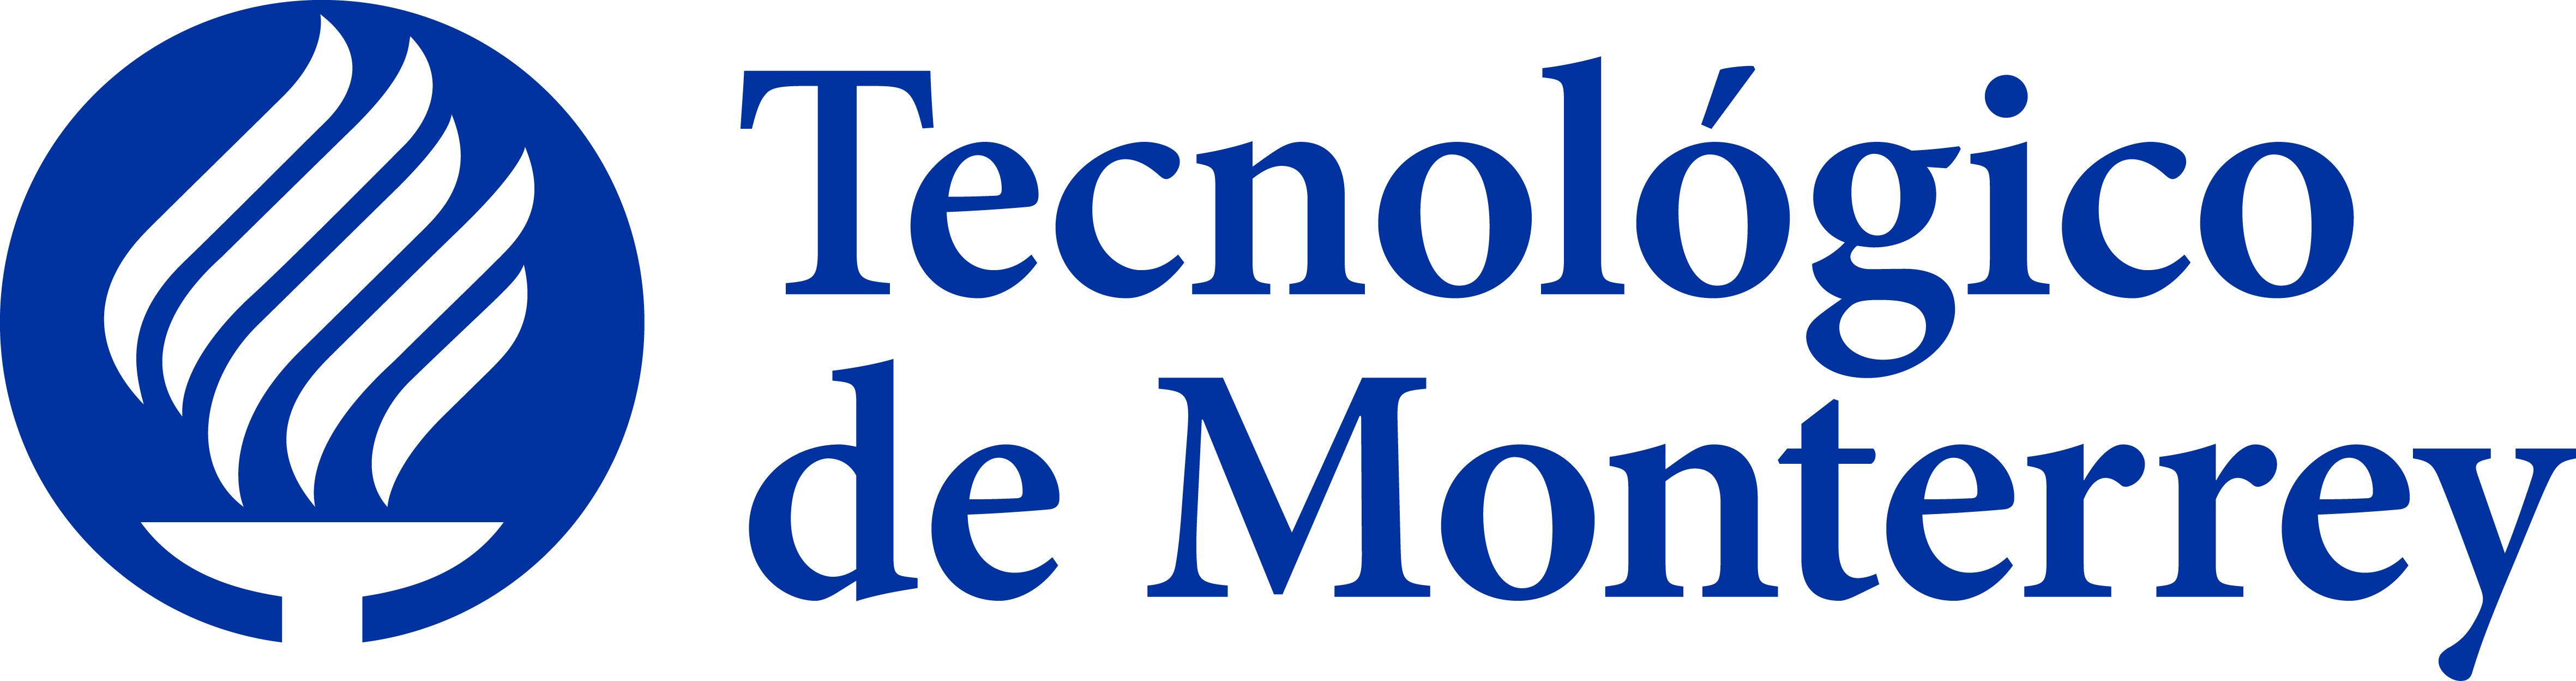



In [1]:
from IPython.core.display import display, HTML

html_content = """
<div style="text-align: center;">
    <h1 style="margin-top: 20px;">Evidence 1. Predictive Model Report</h1>
    <h3>Introduction to Econometrics</h3>
    <p>Group 103</p>
    <p>Atenea López Corona</p>
    <p>A01750999</p>
    <p>August 26, 2024</p>
</div>
"""

#I.Introduction

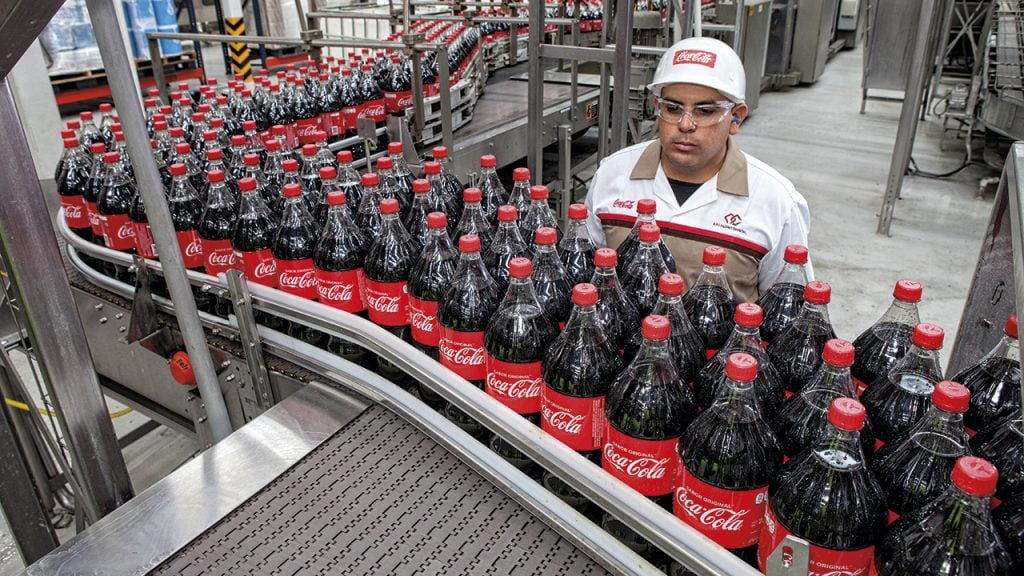

a. Brief description of Coca – Cola Femsa Company.
Coca-cola Femsa Company is the leading bottler and marketer of multi-category beverages in LATAM and the world. It serves more than 272 million people and 2.1 million points of sale in Mexico and abroad.

b. How linear regression analysis is useful for business intelligence? According to Professor Jan Hammond,who teaches at Harvard University, “Regression allows us to gain insights into the structure of that relationship and provides measures of how well the data fit that relationship” (Cote, par:19). It has two important purposes: to study the magnitude and structure of the relationship between variables, without considering causality, and to forecast the dependent and independent variable.

c. What is the problem situation? How to address the problem situation?
The case to solve the problem situation is to know the methodology involved to build a predictive model for Coca-Cola FEMSA Company. This case focuses on predicting the necessary amount of beverages to be produced to meet the demand of the metropolitan area of Guadalajara, Mexico. This with the use of Python language and based on monthly historical data from 2015 to 2018. The path of this case is divided into three sections: first the part of analysis and exploration of the database, where the nulls will be searched and the database will be normalized, second in the part of Hypothesis Statement models and multilinear regressions and, finally, the results and observations of the models.


#**II. Exploratory Data Analysis**

In [2]:
#Uploading database
from google.colab import files
import pandas as pd

uploaded = files.upload()

file = 'cocacolasales.xlsx'
datacoca = pd.read_excel(file)
display(datacoca.head())


Saving cocacolasales.xlsx to cocacolasales.xlsx


,tperiod,sales_unitboxes,consumer_sentiment,CPI,inflation_rate,unemp_rate,gdp_percapita,itaee,itaee_growth,pop_density,job_density,pop_minwage,exchange_rate,max_temperature,holiday_month
0,2021-01-15,5516689.143,38.062504,87.110103,-0.09,0.052303,11659.55571,103.765354,0.049717,98.541847,18.260479,9.657861,14.692586,28,0
1,2021-02-15,5387496.113,37.491143,87.275377,0.19,0.053113,11659.55423,103.765354,0.049717,98.541860,18.463294,9.657861,14.921342,31,0
2,2021-03-15,5886746.634,38.505219,87.630717,0.41,0.046088,11659.55275,103.765354,0.049717,98.541872,18.641639,9.657861,15.228338,29,0
3,2021-04-15,6389182.011,37.842864,87.403840,-0.26,0.051020,11625.74515,107.751835,0.031839,98.828431,18.678763,9.594919,15.226180,32,1
4,2021-05-15,6448274.629,38.031692,86.967366,-0.50,0.055174,11625.74368,107.751835,0.031839,98.828444,18.675393,9.594919,15.264470,34,0


In [3]:
#Libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler


In [4]:
#a. Identify missing values
#Counting of NULLs
#Counting the NA's in the dataset and we see the null values
null_columns = datacoca.isna().any()
print("Columns with null data:")
print(null_columns[null_columns].index.tolist())
#Seeing the NA's in the columns
null_counts = datacoca.isna().sum()
print("\nCount of null data per column:")
print(null_counts)



Columns with null data:
[]

Count of null data per column:
tperiod               0
sales_unitboxes       0
consumer_sentiment    0
CPI                   0
inflation_rate        0
unemp_rate            0
gdp_percapita         0
itaee                 0
itaee_growth          0
pop_density           0
job_density           0
pop_minwage           0
exchange_rate         0
max_temperature       0
holiday_month         0
dtype: int64


There isn't any NULL value.

In [18]:
#b. Display the structure of the dataset
# check the dataset's variables
datacoca.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   tperiod             48 non-null     datetime64[ns]
 1   sales_unitboxes     48 non-null     float64       
 2   consumer_sentiment  48 non-null     float64       
 3   CPI                 48 non-null     float64       
 4   inflation_rate      48 non-null     float64       
 5   unemp_rate          48 non-null     float64       
 6   gdp_percapita       48 non-null     float64       
 7   itaee               48 non-null     float64       
 8   itaee_growth        48 non-null     float64       
 9   pop_density         48 non-null     float64       
 10  job_density         48 non-null     float64       
 11  pop_minwage         48 non-null     float64       
 12  exchange_rate       48 non-null     float64       
 13  max_temperature     48 non-null     int64         
 

In [6]:
#c. Descriptive statistics
datacoca.describe().T

,count,mean,min,25%,50%,75%,max,std
tperiod,48,2021-07-02 00:00:00,2021-01-15 00:00:00,2021-04-08 00:00:00,2021-07-01 12:00:00,2021-09-24 18:00:00,2021-12-18 00:00:00,NaN
sales_unitboxes,48.0,6473690.646562,5301754.832,6171766.505,6461357.144,6819781.79475,7963062.561,598730.045903
consumer_sentiment,48.0,37.15185,28.667872,35.644474,36.760016,38.144293,44.865439,2.889173
CPI,48.0,93.402719,86.967366,89.180915,92.821459,98.403412,103.02,5.058049
inflation_rate,48.0,0.348542,-0.5,0.165,0.385,0.5575,1.7,0.389604
unemp_rate,48.0,0.044419,0.034662,0.040104,0.043687,0.048974,0.055174,0.005881
gdp_percapita,48.0,11978.8963,11558.58701,11830.071728,12013.560335,12161.642717,12329.0465,251.302961
itaee,48.0,113.852442,103.765354,111.483897,113.469365,117.127478,122.482102,4.753228
itaee_growth,48.0,0.031736,0.005571,0.022376,0.029977,0.043038,0.056536,0.014621
pop_density,48.0,100.647189,98.541847,99.614891,100.66591,101.692455,102.694498,1.289906


c. As can be seen in the database, there are more people per km2 who are unemployed and those who do not have a decent or sufficient salary to cover 100% of their needs but enough to buy a drink at less than or equal to the cost of one dollar.

In [7]:
# Selecting numerical variables
datacoca_num_vars = datacoca[["sales_unitboxes", "consumer_sentiment", "gdp_percapita", "CPI","inflation_rate","itaee", "itaee_growth","unemp_rate","pop_minwage","exchange_rate","holiday_month","pop_density","job_density","max_temperature"]]

##**Transformation to natural log**

In [8]:
# Selecting numerical variables
datacoca1 = datacoca.copy()

columns_to_transform = ['itaee', 'max_temperature', 'pop_density']

# Replace negative values with NaN
datacoca1[columns_to_transform] = datacoca1[columns_to_transform].applymap(lambda x: np.nan if x < 0 else x)

# Applying natural logarithm to selected columns
datacoca1[columns_to_transform] = np.log(datacoca1[columns_to_transform] + 1)

# Replace NaN values with a random number
datacoca1[columns_to_transform] = datacoca1[columns_to_transform].applymap(lambda x: x if not pd.isna(x) else np.random.rand())

# Display the first rows to verify the transformation
print(datacoca1.head())


     tperiod  sales_unitboxes  consumer_sentiment        CPI  inflation_rate  \
0 2021-01-15      5516689.143           38.062504  87.110103           -0.09   
1 2021-02-15      5387496.113           37.491143  87.275377            0.19   
2 2021-03-15      5886746.634           38.505219  87.630717            0.41   
3 2021-04-15      6389182.011           37.842864  87.403840           -0.26   
4 2021-05-15      6448274.629           38.031692  86.967366           -0.50   

   unemp_rate  gdp_percapita     itaee  itaee_growth  pop_density  \
0    0.052303    11659.55571  4.651723      0.049717     4.600578   
1    0.053113    11659.55423  4.651723      0.049717     4.600578   
2    0.046088    11659.55275  4.651723      0.049717     4.600578   
3    0.051020    11625.74515  4.689069      0.031839     4.603453   
4    0.055174    11625.74368  4.689069      0.031839     4.603453   

   job_density  pop_minwage  exchange_rate  max_temperature  holiday_month  
0    18.260479     9.657861

<ipython-input-8-9ea4e5b9b33f>:7: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  datacoca1[columns_to_transform] = datacoca1[columns_to_transform].applymap(lambda x: np.nan if x < 0 else x)
<ipython-input-8-9ea4e5b9b33f>:13: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  datacoca1[columns_to_transform] = datacoca1[columns_to_transform].applymap(lambda x: x if not pd.isna(x) else np.random.rand())


The transformation to natural logarithm results in some NA's values, but to improve the model a random value substitution was applied. Otherwise, there was a lot of smoothing of the values and therefore I decide not to apply in all variables the transformation to my predictive models.

#**Vizualization**

Display of the most significant to the least statistically significant variables.

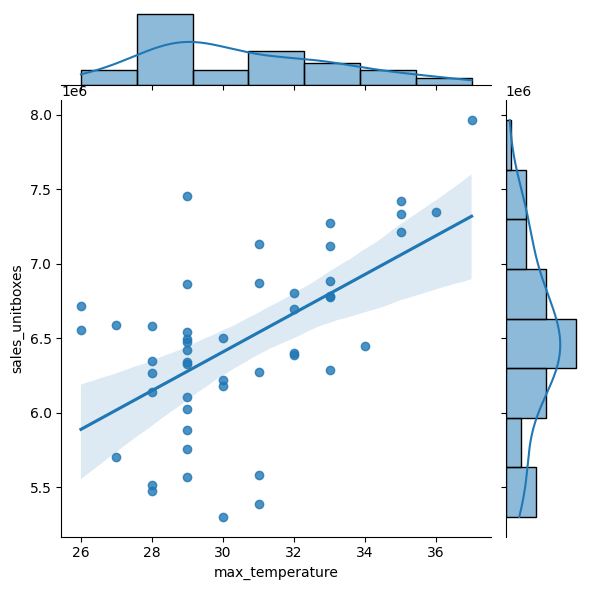

In [19]:
# e.1.1 Data visualization
# e.1 Firts graphic for a variable dependent and independent
# scatterplot between a selected explanatory variable and the dependent variable
sns.jointplot(data=datacoca_num_vars, x='max_temperature', y='sales_unitboxes', kind='reg')
plt.show()


There is a correlation between max_temperature and sales_units, which indicates that the higher the temperature, the higher the sales of beverages. Also there is a positive tendency.

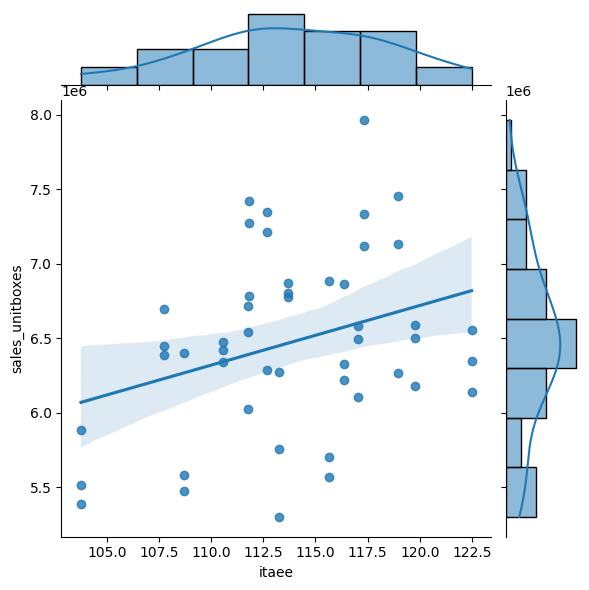

In [20]:
# e.1.2 Second graphic for a variable dependent and independent
# scatterplot between a selected explanatory variable and the dependent variable
sns.jointplot(data=datacoca_num_vars, x='itaee', y='sales_unitboxes', kind='reg')


 This makes sense, since as we observe the 'itaee' also helps to predict that with the miniumum amount of salary from a job a person buys a drink.

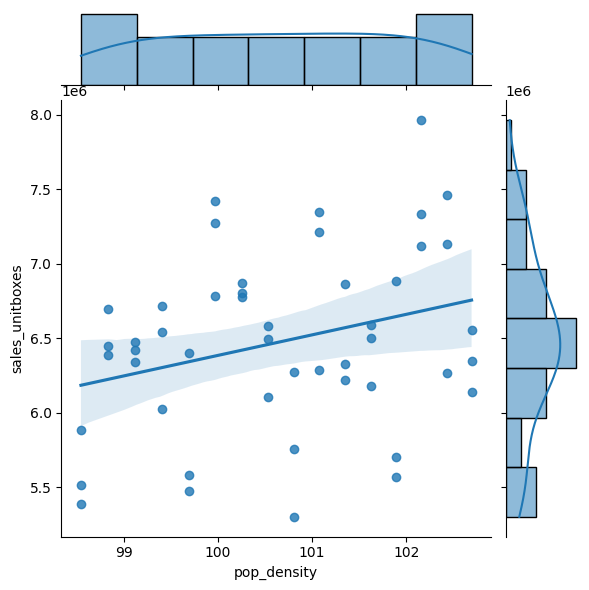

In [11]:
# e.1.3 Third graphic for a variable dependent and independent
# scatterplot between a selected explanatory variable and the dependent variable
sns.jointplot(data=datacoca_num_vars, x='pop_density', y='sales_unitboxes', kind='reg')

As can be seen, there is a positive dispersion of values.

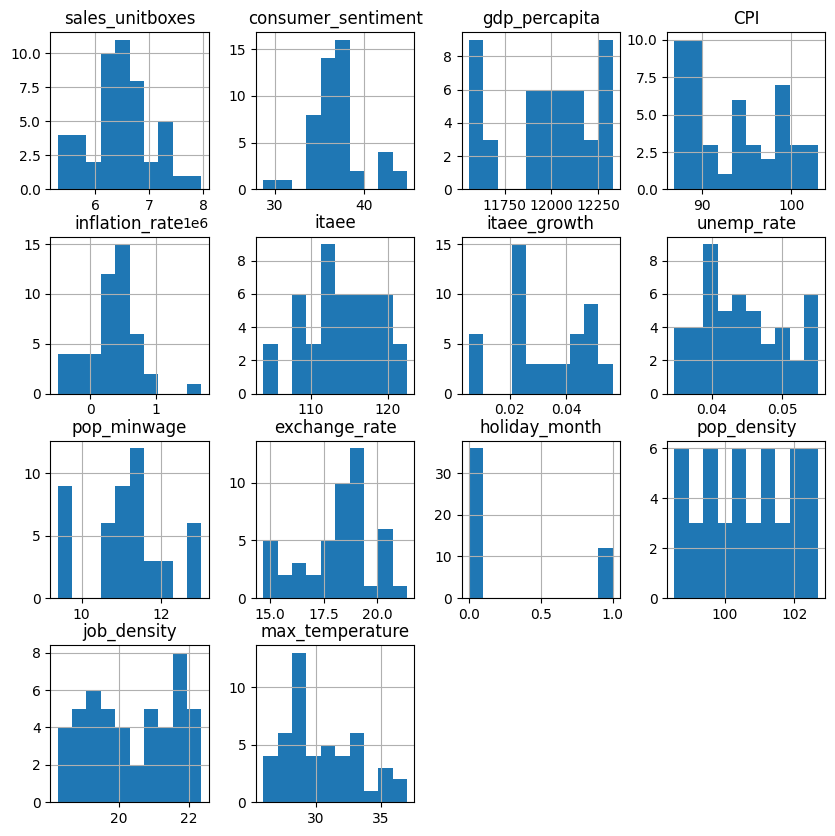

In [21]:
# c.2. Create visualizations (histogram, boxplot, scatter plot, etc.) to understand the patterns in the data.
# Histogram
import matplotlib.pyplot as plt

datacoca_num_vars.hist(figsize=(10,10))

# displaying histogram
plt.show()



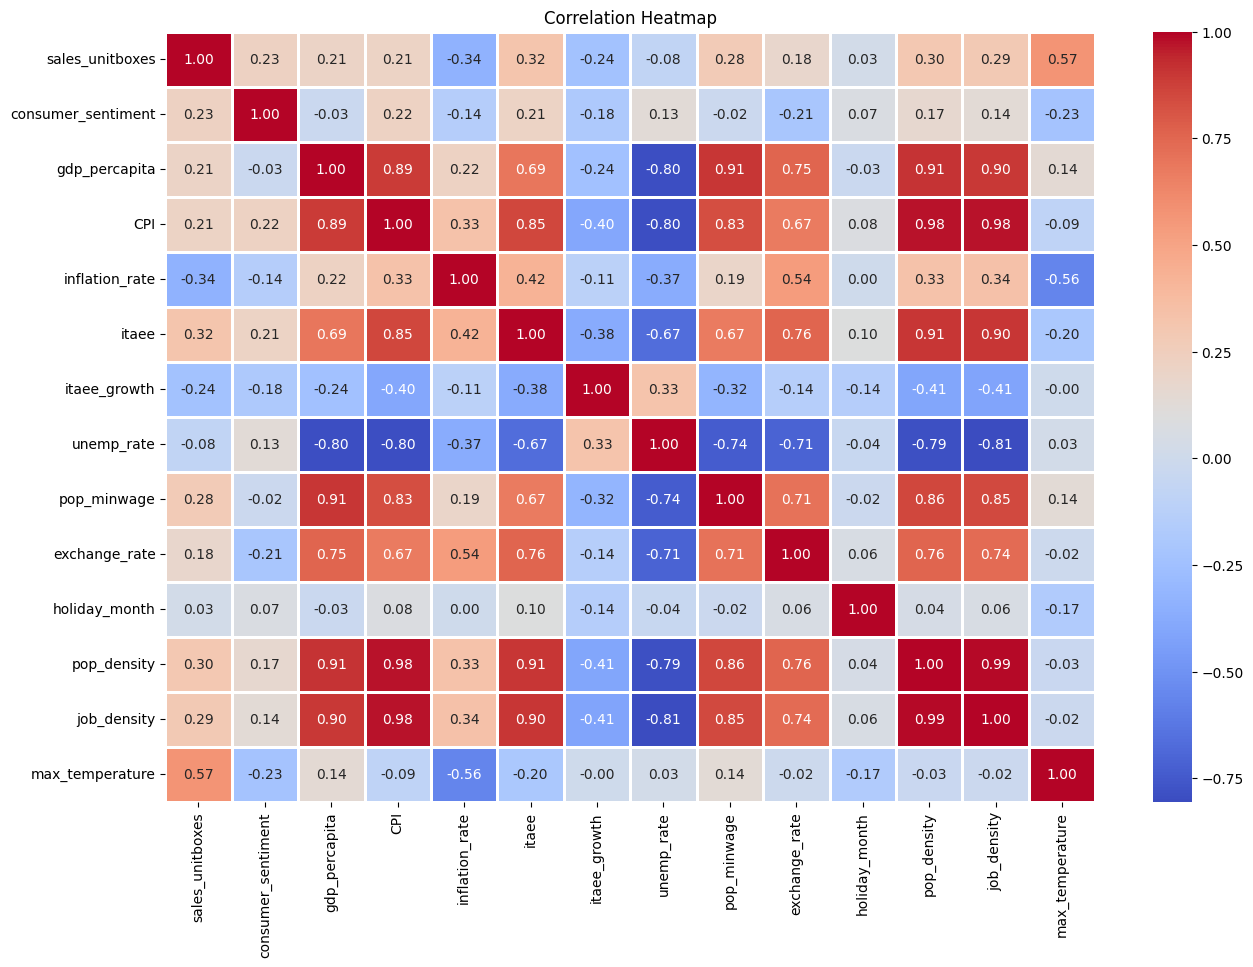

In [22]:
# e.3 Correlation plot
plt.figure(figsize=(15, 10))

# Using library Seaborn to create a correlation heatmap
sns.heatmap(datacoca_num_vars.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=2)

plt.title('Correlation Heatmap')
plt.show()

#III.Model Specification and Setting Hypotheses
X = 'max_temperature','itaee','pop_density'

Y = 'sales_unitboxes'

a.The warmer the Guadalajara metropolitan area is, the more sales will be generated.

b.The more economic activities there are in the area, the more beverages are purchased by consumers.

c. The more people there are in the metropolitan area, the greater the constant or increased consumption of purchases. .

#IV. Multiple Linear Regression
#V. Model Selection and Results Interpretation

**Multiple Linear Regression**

In [14]:
#Multiple linear regression with three variables
#We use another variable to don't touch the original dataset
mlr=datacoca
#We specify the dependent columns and the independent variable, which we will use to predict and which one we are looking to predict.
X = mlr[['itaee','max_temperature','pop_density']]
y = mlr['sales_unitboxes']

#We split the dataset into training and test data, with a random variable for data selection.
#In this way we select 75% of training data and 25% of test data.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=40)

#Then we load the regression model, and train the regression model.
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

#Here we use the test data to try to predict the data we want.
y_pred = linear_model.predict(X_test)

#At this point we also evaluate the model with the AIC formula.
X_train_sm = sm.add_constant(X_train)
linear_model_sm = sm.OLS(y_train, X_train_sm).fit()

print(linear_model_sm.summary())

#The results tell us first that the MSE is very high, which means that the model does not predict well because the difference between the predicted
#result and the obtained result squared is enormous. This indicates that this model is not accurate for prediction.
#As a third indicator we use the AIC which tells us that the lower the AIC the better the model because it measures complexity and overfitting which gives us as a result
#A very high complexity indicator which tells us that the model has too much complexity to overfit.


X_train_vif = sm.add_constant(X_train)

# Calculation of the VIF only in the original variables
vif_data = pd.DataFrame()
vif_data["feature"] = X_train.columns
vif_data["VIF"] = [variance_inflation_factor(X_train_vif.values, i+1) for i in range(X_train.shape[1])]

print(vif_data)

#RMSE calculation and print
Model_1_RMSE = mean_squared_error(y_true=y_test, y_pred=y_pred, squared=False)
print(f'RMSE: {Model_1_RMSE}')

                            OLS Regression Results                            
Dep. Variable:        sales_unitboxes   R-squared:                       0.706
Model:                            OLS   Adj. R-squared:                  0.679
Method:                 Least Squares   F-statistic:                     25.65
Date:                Mon, 26 Aug 2024   Prob (F-statistic):           1.20e-08
Time:                        23:12:30   Log-Likelihood:                -506.87
No. Observations:                  36   AIC:                             1022.
Df Residuals:                      32   BIC:                             1028.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const             2.43e+07    8.2e+06     

*Interpretation*: It is not a good model since there is a strong presence of Multicollinearity in the model, especially with the variables “itaee” and “pop_density” and it is logical since both are related to the population of the Guadalajara metropolitan area. Also, because of a high RMSE and that statistically indicates that there is not a good prediction. Although the R2, JB and Durbin-Watson values are normal within their parameters, caution should be taken when using this model. The most relevant variable is “max_temperature” because with each 2.281e+05 it has a significance value of 99%.

**Polynomial - multiple linear regression**

In [15]:
#Polynomial – multiple linear regression

#Here we assigned the dataset to pmlr1. Then, it is filtered to include only the rows where the age is 55 or older.
#This filtered dataset is stored in pmlr.
pmlr = datacoca

#We put the dependent variable in the y axis and the independent variables in the x axis.
X = pmlr[['exchange_rate','max_temperature','pop_minwage']]
y = pmlr['sales_unitboxes']

#We divide the data into training and test sets.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=40)

#We are appplying the polynomial transformation to the model used to generate polynomial and interaction features up to the specified degree (in this case, 3).
poly = PolynomialFeatures(degree=3)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

#Now we are fitting the Linear Regression Model
p_model = LinearRegression()
p_model.fit(X_train_poly, y_train)

#Here we made some predictions on the scaled test data
y_pred_poly = p_model.predict(X_test_poly)

#We added a constant to the tarining data to prepare it for an Ordinary Least Squares (OLS) regression model. This is necessary because OLS models typically include an intercept.
X_train_poly_sm = sm.add_constant(X_train_poly)
poly_model_sm = sm.OLS(y_train, X_train_poly_sm).fit()

print(poly_model_sm.summary())

# Calculation of the VIF only in the original variables
X_train_vif2 = sm.add_constant(X_train)

vif_data = pd.DataFrame()
vif_data["feature"] = X_train.columns
vif_data["VIF"] = [variance_inflation_factor(X_train_vif2.values, i+1) for i in range(X_train.shape[1])]

print(vif_data)

#RMSE calculation and print
Model_1_RMSE = mean_squared_error(y_true=y_test, y_pred=y_pred, squared=False)
print(f'RMSE: {Model_1_RMSE}')


                            OLS Regression Results                            
Dep. Variable:        sales_unitboxes   R-squared:                       0.837
Model:                            OLS   Adj. R-squared:                  0.643
Method:                 Least Squares   F-statistic:                     4.317
Date:                Mon, 26 Aug 2024   Prob (F-statistic):            0.00240
Time:                        23:12:40   Log-Likelihood:                -496.30
No. Observations:                  36   AIC:                             1033.
Df Residuals:                      16   BIC:                             1064.
Df Model:                          19                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1.375e+08   6.77e+08     -0.203      0.8

*Interpretation*: If we look at the model from top to bottom we can see values that incline the model to a passable model since it has a significant contribution in fitting the values and has an adequate residual value for autocorrelation. Also, it should be considered that it has a multicollinearity problem and high RMSE.  Nevertheless, it is the best model.

**Lasso regression model**

In [16]:
#Lasso regression model
lrm = datacoca

#We put the dependent variable in the y axis and the independent variables in the x axis.
X = lrm[['exchange_rate','max_temperature','pop_minwage']]
y = lrm['sales_unitboxes']

#We divide the data into training and test sets.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=40)


#Now we standardized the features. This step is crucial for regularization techniques like Lasso Regression.
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#creatING the Lasso Regression model which is created with alpha=0.1, which controls the strength of the regularization.
lasso_model = Lasso(alpha=0.1)
lasso_model.fit(X_train_scaled, y_train)

#Here we made some predictions on the scaled test data
y_pred_lasso = lasso_model.predict(X_test_scaled)

#Adding a constant to the tarining data to prepare it for an Ordinary Least Squares (OLS) regression model. This is necessary because OLS models typically include an intercept.
X_train_scaled_sm = sm.add_constant(X_train_scaled)
lasso_model_sm = sm.OLS(y_train, X_train_scaled_sm).fit()

print(lasso_model_sm.summary())

# Calculation of the VIF only in the original variables
X_train_vif1 = sm.add_constant(X_train)

vif_data = pd.DataFrame()
vif_data["feature"] = X_train.columns
vif_data["VIF"] = [variance_inflation_factor(X_train_vif1.values, i + 1) for i in range(X_train.shape[1])]

print(vif_data)

#RMSE calculation and print
Model_1_RMSE = mean_squared_error(y_true=y_test, y_pred=y_pred, squared=False)
print(f'RMSE: {Model_1_RMSE}')

                            OLS Regression Results                            
Dep. Variable:        sales_unitboxes   R-squared:                       0.399
Model:                            OLS   Adj. R-squared:                  0.343
Method:                 Least Squares   F-statistic:                     7.094
Date:                Mon, 26 Aug 2024   Prob (F-statistic):           0.000872
Time:                        23:12:46   Log-Likelihood:                -519.75
No. Observations:                  36   AIC:                             1047.
Df Residuals:                      32   BIC:                             1054.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       6.465e+06   7.97e+04     81.149      0.0

*Interpretation*: Compared to the previous models, it is observed that there are no problems with multicollinearity and that the model is significant at a certain point. However, when evaluating the other components of the results it is observed that there is not much variability and that there is a high RMSE in the future predictions.

**Ridge regression model**

In [17]:
#Ridge regression model
#We assigned the data set to rrm.
rrm = datacoca

#We put the dependent variable in the y axis and the independent variables in the x axis.
X = rrm[['exchange_rate','max_temperature','pop_minwage']]
y = rrm['sales_unitboxes']

#We divide the data into training and test sets.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=40)

#Now we standarized the features. This step is crucial for regularization techniques like Ridge Regression, which are sensitive to the scale of the input data.
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#We create the Ridge Regression model which controls the strength of the regularization.
ridge_model = Ridge(alpha=0.1)
ridge_model.fit(X_train_scaled, y_train)

#Here we made some predictions on the scaled test data
y_pred_ridge = ridge_model.predict(X_test_scaled)

#We added a constant to the tarining data to prepare it for an Ordinary Least Squares (OLS) regression model.
#This is necessary because OLS models typically include an intercept.
X_train_scaled_sm = sm.add_constant(X_train_scaled)
ridge_model_sm = sm.OLS(y_train, X_train_scaled_sm).fit()

print(ridge_model_sm.summary())

#The Ridge regression model showed consistent results with a clear impact of the variables on insurance costs,
#as evidenced by the mean squared error (MSE) and the R2 value, which was closer to 1 compared to other models.
#The Akaike Information Criterion (AIC) was slightly high, but comparable to other models, with the polynomial model
#performing slightly better. The results were influenced by the limited data available in the database.

# Calculation of the VIF in the original variables
X_train_vif = sm.add_constant(X_train)

vif_data = pd.DataFrame()
vif_data["feature"] = X_train.columns
vif_data["VIF"] = [variance_inflation_factor(X_train_vif.values, i + 1) for i in range(X_train.shape[1])]

print(vif_data)

#RMSE calculation and print
Model_1_RMSE = mean_squared_error(y_true=y_test, y_pred=y_pred, squared=False)
print(f'RMSE: {Model_1_RMSE}')

                            OLS Regression Results                            
Dep. Variable:        sales_unitboxes   R-squared:                       0.399
Model:                            OLS   Adj. R-squared:                  0.343
Method:                 Least Squares   F-statistic:                     7.094
Date:                Mon, 26 Aug 2024   Prob (F-statistic):           0.000872
Time:                        23:12:53   Log-Likelihood:                -519.75
No. Observations:                  36   AIC:                             1047.
Df Residuals:                      32   BIC:                             1054.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       6.465e+06   7.97e+04     81.149      0.0

*Interpretation*: In short, it is the worst model of all, since all the resulting components do not give good results for a meaningful prediction. From values such as R2, RMSE and most of them all show that this model should not be used.

#VI. Conclusions

a. Briefly describe the main 5 – 7 insights identified through EDA and the multiple linear regression process.



*   The best model is the Polynomial - multiple linear regression model as it set a high standard among all the other models by yielding autocorrelation, variability and other components.
*   The use of the transformation of specific data to natural logarithms improved the quality of the models, except for the Ridge regression model.
*   The database is ultimately highly biased, therefore, it is not advisable to expect a high quality predictive model.
*   The independent variables are understandable to me since both are related to the amount of beverages a person can consume, from the economic, population and regional weight.
*   It is necessary to balance the weight of the resulting variables, since many times between them the model is rejected or accepted, and it is chosen through the amount of data.








#VI.References


FEMSA. (2024, 22 marzo). Coca-Cola FEMSA - FEMSA. https://www.femsa.com/es/unidades-de-negocio/coca-cola-femsa/

What Is Regression Analysis in Business Analytics? (2021, 14 diciembre). Business Insights Blog. https://online.hbs.edu/blog/post/what-is-regression-analysis